# Libraries

In [1]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 43.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
from collections import Counter
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
from collections import Counter
import emoji

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

from sklearn.model_selection import train_test_split
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    RobertaForSequenceClassification,
    XLMRobertaForSequenceClassification,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    mean_absolute_error,
    mean_squared_error, r2_score,
)
from tqdm.auto import tqdm
import time, json, os, gc

Here, we installed and load the libraries needed for the end to end training process, including the emojis to process and detecting them in the social media texts, styling the graphic to be more properly with the same figure size. The libraries for ML and transformel models and evaluation metrics also imported.

In [3]:
# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


In [4]:
# Clear any existing CUDA state
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
gc.collect()

90

First, checking the available GPU anc cleaned the GPU memory. As we can see the python succesfully removed 90 objects from the memory.

# Load Data

In [5]:
df = pd.read_csv('/content/MITweet_Translated_Slang.csv')

In [6]:
df.head()

,tweet,label,tweet_translated
0,Forget about protecting the people and communi...,1,they Lupakan supposed continue tentang melindu...
1,Are you with an #environmentalnonprofit leadin...,0,Apakah lu dengan and #environmentalnonprofit w...
2,Curious if #IRA can help you electrify your ho...,1,Penasaran apakah #IRA bisa handy INCREDIBLE me...
3,Learn more from \n on how huge investments fro...,0,& Pelajari lebih transitions lanjut dari pada ...
4,Almost a year since this Vox video on grid cha...,1,Hampir setahun sejak Vox curtain video Vox di ...


In [7]:
df = df[['tweet_translated', 'label']]

In [8]:
df.head()

,tweet_translated,label
0,they Lupakan supposed continue tentang melindu...,1
1,Apakah lu dengan and #environmentalnonprofit w...,0
2,Penasaran apakah #IRA bisa handy INCREDIBLE me...,1
3,& Pelajari lebih transitions lanjut dari pada ...,0
4,Hampir setahun sejak Vox curtain video Vox di ...,1


# EDA

## Data Quality

In [9]:
# Basic Dataset Overview
print("Dataset Columns:")
print(df.columns)
print("\n" + "="*50)

print("\nDataset Shape:", df.shape)

Dataset Columns:
Index(['tweet_translated', 'label'], dtype='object')


Dataset Shape: (5065, 2)


In [10]:
# Basic Dataset Overview
print("Dataset Columns:")
print(df.columns)
print("\n" + "="*50)

print("\nDataset Shape:", df.shape)

Dataset Columns:
Index(['tweet_translated', 'label'], dtype='object')


Dataset Shape: (5065, 2)


In [11]:
print("\nMissing values:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nVery short tweets (<=3 words):", (df['tweet_translated'].str.split().str.len() <= 3).sum())


Missing values:
 tweet_translated    0
label               0
dtype: int64

Duplicate rows: 0

Very short tweets (<=3 words): 0


Here we checks the basic general checking such as the columns and shape. as we can see the dataset now only consist of 2 columns with 5065 rows. And also this dataset is clean without any existing missing and duplicated values. There are also detected no very short tweets.

## Label Distribution


Label Distribution:
 label
1    2947
0    2118
Name: count, dtype: int64

Label Proportion:
 label
1    0.581836
0    0.418164
Name: proportion, dtype: float64


/tmp/ipython-input-978786403.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='viridis')


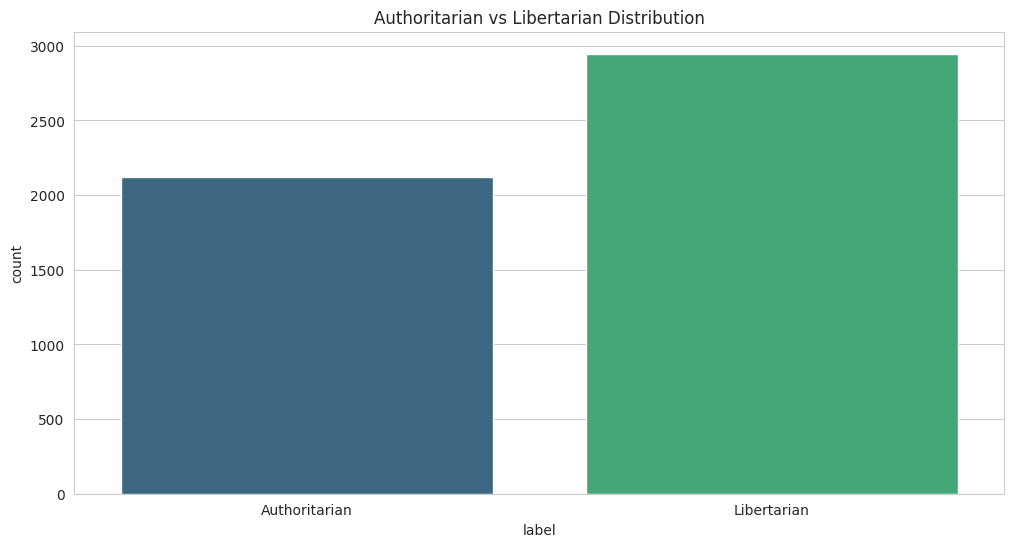

In [12]:
# Label Distribution
print("\nLabel Distribution:\n", df['label'].value_counts())
print("\nLabel Proportion:\n", df['label'].value_counts(normalize=True))

sns.countplot(data=df, x='label', palette='viridis')
plt.title("Authoritarian vs Libertarian Distribution")
plt.xticks([0,1], ["Authoritarian", "Libertarian"])
plt.show()

Now checking the label distributions to gain insight, as we can see this dataset label is quite balanced with the proportion around 0.582 and 0.418 with the real amount of 2947 and 2118 rows of each labels. We can conclude that this dataset is slightly a bit dominated by the libertarian leaning social media users.

In [13]:
print("\nSummary Stats per Label:")
print(df.groupby('label')['tweet_translated'].agg([
    ('count', 'count'),
    ('avg_length', lambda x: x.str.len().mean()),
    ('avg_words', lambda x: x.str.split().str.len().mean()),
    ('max_length', lambda x: x.str.len().max()),
    ('min_length', lambda x: x.str.len().min()),
]).round(2))


Summary Stats per Label:
       count  avg_length  avg_words  max_length  min_length
label                                                      
0       2118      251.20      35.95         504          47
1       2947      261.68      38.17         533          48


In [14]:
# Check for class imbalance
print("\n" + "="*50)
print("CLASS IMBALANCE ANALYSIS")
print("="*50)

label_counts = df.value_counts()
imbalance_ratio = label_counts.max() / label_counts.min()

print(f"\nImbalance ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 1.5:
    print("\nDataset is IMBALANCED (ratio > 1.5:1)")
else:
    print("\nDataset is BALANCED")


CLASS IMBALANCE ANALYSIS

Imbalance ratio: 1.00:1

Dataset is BALANCED


## Text Statistics

In [15]:
# Text Statistics
all_words = " ".join(df['tweet_translated']).split()
vocab = set(all_words)
print("\nVocabulary size:", len(vocab))
print("\nTop 30 tokens:", Counter(all_words).most_common(30))


Vocabulary size: 30511

Top 30 tokens: [('untuk', 4584), ('di', 2440), ('yg', 1966), ('yang', 1911), ('dan', 1801), ('dn', 1799), ('the', 1573), ('to', 1534), ('mereka', 1514), ('kita', 1425), ('wanita', 1411), ('adalah', 1269), ('dari', 1183), ('dengan', 1181), ('hak', 1173), ('ini', 1159), ('tdk', 1154), ('tidak', 1048), ('a', 930), ('of', 901), ('and', 860), ('dalam', 831), ('pada', 809), ('aborsi', 807), ('seorang', 753), ('bahwa', 695), ('tentang', 662), ('gw', 653), ('in', 627), ('itu', 624)]


In [16]:
# Sample Tweets by Label
print("Sample Authoritarian Tweets (Label 0):")
print(df[df['label'] == 0]['tweet_translated'].head(3).to_string())
print("\n" + "="*50 + "\n")
print("Sample Libertarian Tweets (Label 1):")
print(df[df['label'] == 1]['tweet_translated'].head(3).to_string())

Sample Authoritarian Tweets (Label 0):
1    Apakah lu dengan and #environmentalnonprofit w...
3    & Pelajari lebih transitions lanjut dari pada ...
6    and Apa gunanya mempersiapkan infrastruktur Co...


Sample Libertarian Tweets (Label 1):
0    they Lupakan supposed continue tentang melindu...
2    Penasaran apakah #IRA bisa handy INCREDIBLE me...
4    Hampir setahun sejak Vox curtain video Vox di ...


In [17]:
def count_hashtags(text): return len(re.findall(r"#\w+", text))
def count_mentions(text): return len(re.findall(r"@\w+", text))
def count_emojis(text): return sum(c in emoji.EMOJI_DATA for c in text)

In [18]:
hashtag_counts = df['tweet_translated'].apply(count_hashtags)
mention_counts = df['tweet_translated'].apply(count_mentions)
emoji_counts = df['tweet_translated'].apply(count_emojis)

def percentage_stats(series, label):
    total = len(series)
    zero = (series == 0).sum()
    one = (series == 1).sum()
    two_plus = (series >= 2).sum()

    print(f"\n=== {label} Stats ===")
    print(f"No {label.lower()}: {zero} ({zero/total*100:.2f}%)")
    print(f"Has 1 {label.lower()}: {one} ({one/total*100:.2f}%)")
    print(f"Has 2+ {label.lower()}: {two_plus} ({two_plus/total*100:.2f}%)")

percentage_stats(hashtag_counts, "Hashtags")
percentage_stats(mention_counts, "Mentions")
percentage_stats(emoji_counts, "Emojis")


=== Hashtags Stats ===
No hashtags: 3073 (60.67%)
Has 1 hashtags: 687 (13.56%)
Has 2+ hashtags: 1305 (25.77%)

=== Mentions Stats ===
No mentions: 5065 (100.00%)
Has 1 mentions: 0 (0.00%)
Has 2+ mentions: 0 (0.00%)

=== Emojis Stats ===
No emojis: 5047 (99.64%)
Has 1 emojis: 17 (0.34%)
Has 2+ emojis: 1 (0.02%)


Making a function to count the occurences of hashtags, mentions, and emojis. As we can see that from all the texts, most of them didn't consisft of any hashtags, mentions, and emojis. There are might be some texts that have hashtags, mentions, and emojis, but the population are so small (most of them less than 15%). So basically the tweet dataset is dominated by the original / normal texts.

In [19]:
# Slang Ratio
slang_dict = {
    # Pronouns / People
    "saya": "gw", "aku": "gue", "kami": "kita", "kamu": "lu", "anda": "lu",
    "dia": "dia", "mereka": "mereka", "teman": "temen", "kawan": "sob",
    "saudara": "bro", "istri": "bini", "suami": "laki", "ayah": "bokap",
    "ibu": "nyokap", "anak": "bocah", "orang": "org",

    # Verbs
    "pergi": "cabut", "datang": "dateng", "makan": "makan", "minum": "ngopi",
    "berbicara": "ngomong", "bicara": "ngomong", "melihat": "ngeliat",
    "menunggu": "nunggu", "membaca": "baca", "menulis": "nulis",
    "belajar": "belajar", "mengerti": "ngerti", "paham": "ngeh",
    "membeli": "beli", "memakai": "make", "mengambil": "ngambil",
    "mengirim": "ngirim", "menjawab": "bales", "memberikan": "ngasih",
    "mengerjakan": "ngerjain",

    # Negations / Modals
    "tidak": "ga", "nggak": "ga", "bukan": "bukannya", "akan": "bakal",
    "ingin": "pengen", "sudah": "udah", "belum": "blm", "harus": "musti",
    "dapat": "bisa", "mungkin": "mungkin aja", "kenapa": "ngapa",
    "bagaimana": "gimana", "apa": "apaan",

    # Expressions
    "sekali": "banget", "sangat": "super", "benar": "bener",
    "asal": "aslinya", "ternyata": "ternyata loh", "serius": "seriusan",
    "parah": "parah banget", "lelah": "capek", "menyedihkan": "sedih banget",
    "kecewa": "ilfil", "marah": "kesel", "bodoh": "bege", "jelek": "ampas",
    "bagus": "keren", "hebat": "mantap", "lucu": "ngakak",

    # Chat Slang
    "tertawa": "wkwk", "ketawa": "wkwkwk", "lol": "wkwk", "sungguh": "anjir",
    "astaga": "anjay", "wow": "gila sih", "bodoh sekali": "goblok banget",

    # Shortenings
    "yang": "yg", "dan": "dn", "kamu": "km", "sudah": "sdh",
    "tidak": "tdk", "terima kasih": "makasih", "tolong": "pls",
    "banget": "bgt", "sekali": "scl", "ayo": "yuk",

    # Places
    "rumah": "rumah", "sekolah": "skul", "kampus": "kampus",
    "kantor": "kantor", "tempat kerja": "workplace", "jalan": "jalanan",
    "mobil": "mobe", "motor": "montor", "kota": "kota", "desa": "kampung",

    # Gaul
    "iya": "iyaa", "enggak": "ga", "maksudnya": "mksdnya",
    "gila": "gilaaa", "keren": "keren sumpah", "mantap": "mantul",
    "oke": "oke lah", "bro": "cuy", "maaf": "sorry",

    # Politics / Social Commentary
    "politik": "perpolan", "pemerintah": "pemerintah",
    "kebijakan": "kbijakan", "kampanye": "kampanye",
    "pemilu": "pemilu", "isu": "isu", "berita": "news", "media": "medsos",
    "partai": "partai", "korupsi": "korup", "demokrasi": "demo",
    "kritik": "nyinyir", "menolak": "nolakin"
}

In [20]:
# count actual slang usage in dataset
def count_slang_usage(texts, slang_dict):
    slang_counter = Counter()

    for text in tqdm(texts, desc="Counting slang usage"):
        words = text.lower().split()
        for word in words:
            # Check if word is in slang dictionary values
            if word in slang_dict.values():
                slang_counter[word] += 1

    return slang_counter

In [21]:
# Count slang usage
slang_usage = count_slang_usage(df['tweet_translated'], slang_dict)
slang_usage

Counting slang usage:   0%|          | 0/5065 [00:00<?, ?it/s]

Counter({'tdk': 1154,
         'yg': 1966,
         'dn': 1799,
         'mereka': 1529,
         'bisa': 588,
         'lu': 456,
         'isu': 12,
         'rumah': 112,
         'jalanan': 26,
         'kita': 1507,
         'gw': 653,
         'baca': 31,
         'dia': 574,
         'perpolan': 37,
         'kampanye': 29,
         'bakal': 588,
         'partai': 102,
         'kbijakan': 33,
         'cabut': 58,
         'ngeliat': 127,
         'apaan': 205,
         'gimana': 143,
         'org': 379,
         'ngomong': 92,
         'medsos': 26,
         'news': 45,
         'pengen': 178,
         'dateng': 70,
         'gue': 337,
         'ngerti': 25,
         'capek': 10,
         'ngasih': 48,
         'pemilu': 22,
         'mobe': 8,
         'pemerintah': 109,
         'super': 123,
         'kota': 46,
         'keren': 11,
         'make': 103,
         'bukannya': 147,
         'ngakak': 3,
         'blm': 52,
         'ngambil': 114,
         'pls': 31,
    

In [22]:
# Get top 20 most frequent slang terms
top_slang = dict(sorted(slang_usage.items(), key=lambda x: x[1], reverse=True)[:20])
top_slang

{'yg': 1966,
 'dn': 1799,
 'mereka': 1529,
 'kita': 1507,
 'tdk': 1154,
 'gw': 653,
 'bisa': 588,
 'bakal': 588,
 'dia': 574,
 'lu': 456,
 'org': 379,
 'gue': 337,
 'musti': 297,
 'apaan': 205,
 'pengen': 178,
 'bukannya': 147,
 'gimana': 143,
 'ngeliat': 127,
 'super': 123,
 'ngambil': 114}

Here, we defining the slang dictionary to detect the informal language in the tweet discussions, and then counting the number of times of slang word occurences in the entire tweet. As we can see, the output of the counter slang is succesfully count all the slang occurences in the entire tweet dataset. This means that the twitter text is dominated by a informal language or consists of many abbreviation. Therefore a normalization process is needed to improve the text representation quality.

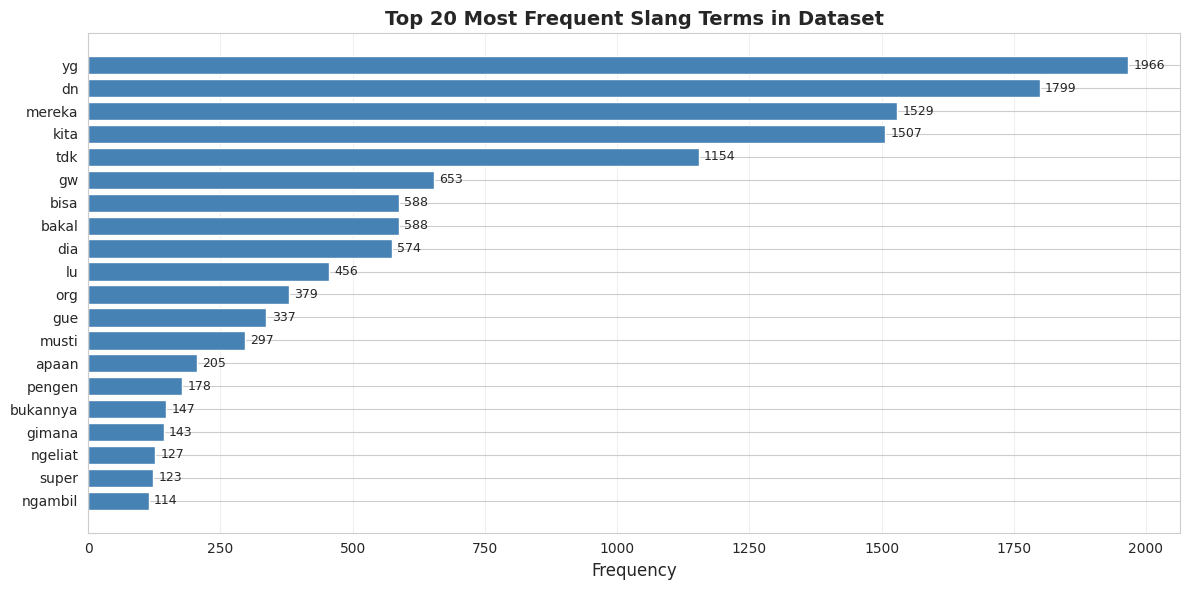


SLANG ANALYSIS SUMMARY
Total unique slang terms found in dataset: 88
Total slang occurrences: 14655


In [23]:
# Plot Most Frequent Slang Terms
# Plot 1: Most Frequent Slang Terms Actually Used
if top_slang:
    plt.barh(list(top_slang.keys()), list(top_slang.values()), color='steelblue')
    plt.xlabel('Frequency', fontsize=12)
    plt.title('Top 20 Most Frequent Slang Terms in Dataset', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)

    # Add value labels
    for i, (word, count) in enumerate(top_slang.items()):
        plt.text(count + 10, i, str(count), va='center', fontsize=9)
else:
    plt.text(0.5, 0.5, 'No slang terms found in dataset',
                ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Top 20 Most Frequent Slang Terms in Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("SLANG ANALYSIS SUMMARY")
print("="*60)
print(f"Total unique slang terms found in dataset: {len(slang_usage)}")
print(f"Total slang occurrences: {sum(slang_usage.values())}")
print("="*60)

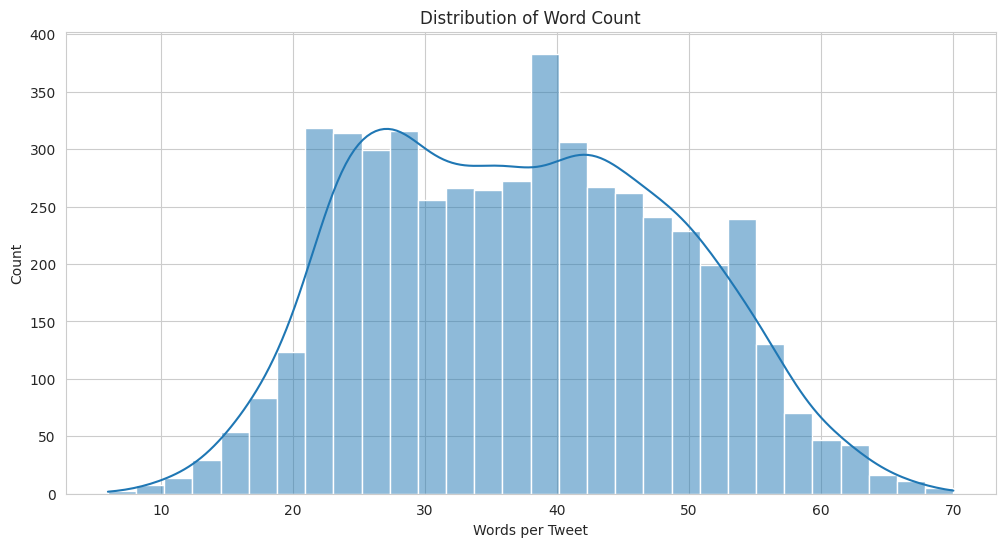

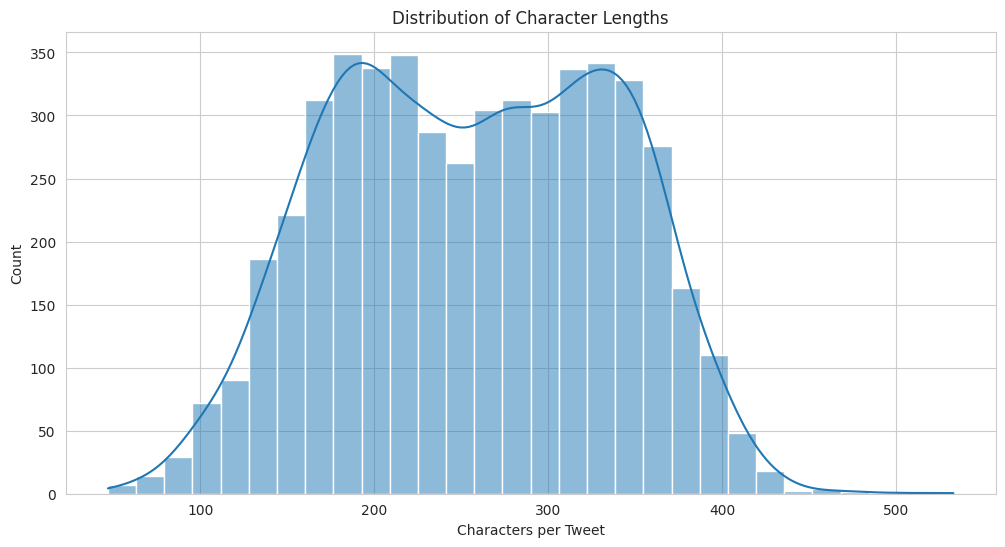

In [24]:
# Text Distribution
word_counts = df['tweet_translated'].str.split().str.len()
char_lengths = df['tweet_translated'].str.len()

sns.histplot(word_counts, bins=30, kde=True)
plt.title("Distribution of Word Count")
plt.xlabel("Words per Tweet")
plt.show()

sns.histplot(char_lengths, bins=30, kde=True)
plt.title("Distribution of Character Lengths")
plt.xlabel("Characters per Tweet")
plt.show()

As we can see from both of the plot above, that most of the tweet have around 20 to 40 words and 200 to 350 characters per tweet which indicating that users tend to write the opinion quite long, not just a short text. The distribution which slightly skewed left which means that only a few parts of tweets that is really long.

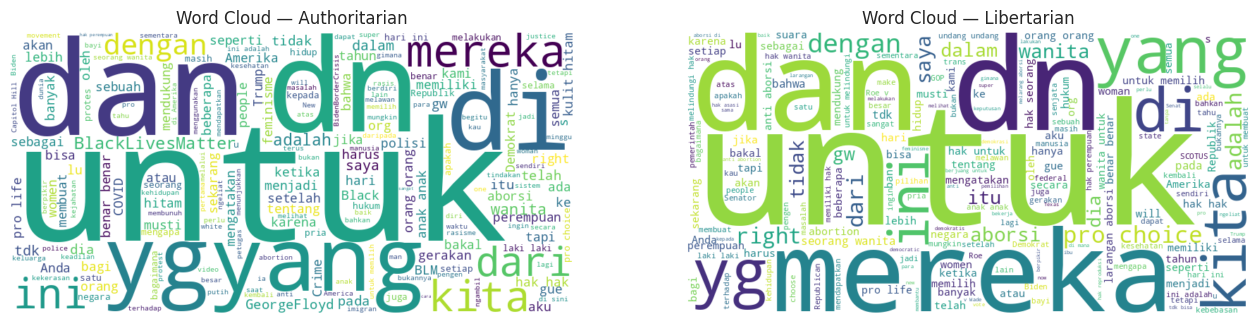

In [25]:
# World Clouds
fig, axes = plt.subplots(1,2, figsize=(16,6))
label_names = {0:"Authoritarian", 1:"Libertarian"}

for idx, label in enumerate([0,1]):
    text = " ".join(df[df['label']==label]['tweet_translated'])
    wc = WordCloud(width=800, height=400, background_color='white').generate(text)
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(f"Word Cloud — {label_names[label]}")
    axes[idx].axis("off")
plt.show()

Showing the word clouds for both labels, with the bigger the words means that it appear the most. From both labels, "untuk, "dn", "dan", etc are the most often appearing words.

In [26]:
q1 = word_counts.quantile(0.25)
q3 = word_counts.quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr
print("\nTweets considered outliers (long text):", (word_counts > upper).sum())


Tweets considered outliers (long text): 0


# Preprocess

## Split Data for Preprocess

In [27]:
# rename column untuk mempermudah
X = df['tweet_translated']
y = df['label']

In [28]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)

print("Train size:", len(train_texts))
print("Test size:", len(test_texts))

Train size: 4052
Test size: 1013


In [29]:
train_texts.head()

,tweet_translated
361,Semua orang Trump's di seluruh dunia sedang me...
4541,Yall perempuan bege seperti that neraka berpik...
2493,super only come mudah the be The jika undang-u...
518,need Texans layak is mendapatkan yg lebih baik...
4118,you Google map me Mossque near me type karo. H...


In [30]:
print("Checking label validity...")
print(f"Train labels unique values: {train_labels.unique()}")
print(f"Test labels unique values: {test_labels.unique()}")
print(f"Train labels range: [{train_labels.min()}, {train_labels.max()}]")
print(f"Test labels range: [{test_labels.min()}, {test_labels.max()}]")
print(f"Any NaN in train: {train_labels.isna().sum()}")
print(f"Any NaN in test: {test_labels.isna().sum()}")

Checking label validity...
Train labels unique values: [0 1]
Test labels unique values: [1 0]
Train labels range: [0, 1]
Test labels range: [0, 1]
Any NaN in train: 0
Any NaN in test: 0


## Preprocess

In [31]:
def analyze_tweet_lengths(texts, tokenizer):
    lengths = []
    for text in tqdm(texts, desc="Analyzing lengths"):
        tokens = tokenizer.encode(str(text), add_special_tokens=True)
        lengths.append(len(tokens))

    lengths = np.array(lengths)
    print(f"Mean length: {lengths.mean():.2f}")
    print(f"Median length: {np.median(lengths):.2f}")
    print(f"95th percentile: {np.percentile(lengths, 95):.2f}")
    print(f"96th percentile: {np.percentile(lengths, 96):.2f}")
    print(f"97th percentile: {np.percentile(lengths, 97):.2f}")
    print(f"98th percentile: {np.percentile(lengths, 98):.2f}")
    print(f"99th percentile: {np.percentile(lengths, 99):.2f}")
    print(f"Max length: {lengths.max()}")

    plt.figure(figsize=(10, 5))
    plt.hist(lengths, bins=50, edgecolor='black')
    plt.xlabel('Token Length')
    plt.ylabel('Frequency')
    plt.title('Distribution of Tweet Token Lengths')
    plt.axvline(np.percentile(lengths, 95), color='r', linestyle='--', label='95th percentile')
    plt.legend()
    plt.show()

    return lengths

In [32]:
tokenizer = BertTokenizer.from_pretrained("bert-base-multilingual-cased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

Analyzing lengths:   0%|          | 0/5065 [00:00<?, ?it/s]

Mean length: 67.57
Median length: 67.00
95th percentile: 101.00
96th percentile: 103.00
97th percentile: 105.00
98th percentile: 110.00
99th percentile: 118.00
Max length: 184


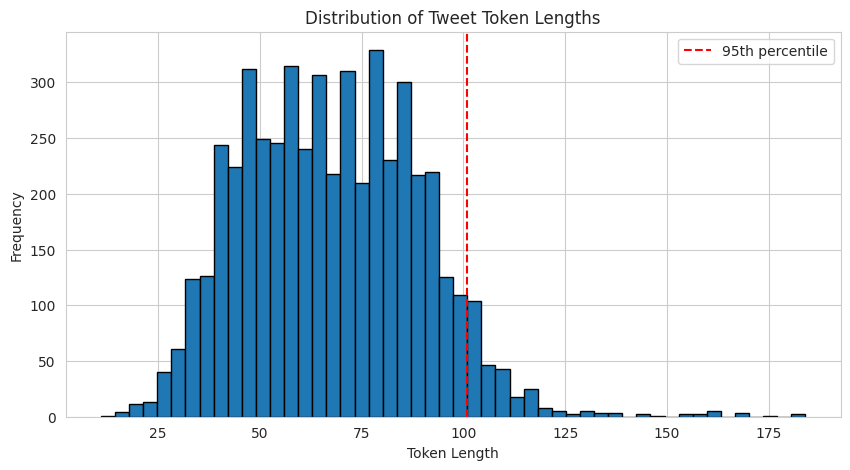

In [33]:
lengths = analyze_tweet_lengths(df['tweet_translated'], tokenizer)

Defining a function to analyze the length of the tweet after being tokenized, including the mean, median, quantiles, and max length, and plotting the distribution. Load the bert pre-trained tokenizer. As we can see the average length is around 67 and the median is 67, from the plot we can conclude that most of the text length is aroung 40-90 tokens and 95 perecents of tweets are shorter than 101 tokens, while only a very small fraction exceeds 130 tokens.

In [34]:
# Use 95th percentile for MAX_LEN to avoid excessive padding
MAX_LEN = int(np.percentile(lengths, 95))
print(f"MAX_LEN: {MAX_LEN}")

MAX_LEN: 101


In [35]:
def clean_text(text):
    text = str(text)

    # remove URL
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # remove weird unicode
    text = text.encode("ascii", "ignore").decode()

    # normalize repeated chars ("anjiiiiir" → "anjir")
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # remove symbols except letters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # lowercase
    text = text.lower()

    # strip extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


In [36]:
slang_standardization = {
    # Pronouns / People
    "gw": "saya", "gue": "saya", "lu": "kamu",
    "temen": "teman", "sob": "kawan", "bro": "saudara",
    "bini": "istri", "laki": "suami", "bokap": "ayah",
    "nyokap": "ibu", "bocah": "anak", "org": "orang",

    # Verbs
    "cabut": "pergi", "dateng": "datang", "ngopi": "minum",
    "ngomong": "berbicara", "ngeliat": "melihat",
    "nunggu": "menunggu", "nulis": "menulis",
    "ngerti": "mengerti", "ngeh": "paham",
    "make": "memakai", "ngambil": "mengambil",
    "ngirim": "mengirim", "bales": "menjawab", "ngasih": "memberikan",
    "ngerjain": "mengerjakan",

    # Negations / Modals
    "ga": "tidak", "nggak": "tidak", "gak": "tidak",
    "enggak": "tidak", "bukannya": "bukan", "bakal": "akan",
    "pengen": "ingin", "udah": "sudah", "blm": "belum", "musti": "harus",
    "ngapa": "kenapa", "gimana": "bagaimana", "apaan": "apa",

    # Expressions
    "banget": "sekali", "bgt": "sekali", "super": "sangat", "bener": "benar",
    "aslinya": "asal", "ternyata loh": "ternyata", "seriusan": "serius",
    "parah banget": "parah", "capek": "lelah", "sedih banget": "menyedihkan",
    "ilfil": "kecewa", "kesel": "marah", "bege": "bodoh", "ampas": "jelek",
    "keren": "bagus", "mantap": "hebat", "ngakak": "lucu",
    "keren sumpah": "bagus", "mantul": "mantap",

    # Chat Slang
    "wkwk": "tertawa", "wkwkwk": "tertawa", "anjir": "sungguh",
    "anjay": "astaga", "gila sih": "wow", "goblok banget": "bodoh sekali",
    "gilaaa": "gila",

    # Shortenings
    "yg": "yang", "dn": "dan", "km": "kamu", "sdh": "sudah",
    "tdk": "tidak", "makasih": "terima kasih", "pls": "tolong",
    "scl": "sekali", "yuk": "ayo", "mksdnya": "maksudnya",
    "iyaa": "iya", "oke lah": "oke", "cuy": "bro",

    # Places
    "skul": "sekolah", "jalanan": "jalan",
    "mobe": "mobil", "montor": "motor", "kampung": "desa",
    "workplace": "tempat kerja",

    # Politics / Social Commentary
    "perpolan": "politik", "kbijakan": "kebijakan",
    "news": "berita", "medsos": "media",
    "korup": "korupsi", "demo": "demokrasi",
    "nyinyir": "kritik", "nolakin": "menolak"
}

In [37]:
def standardize_slang(text, slang_dict):
    words = text.split()
    standardized = []

    for word in words:
        # Remove punctuation from word for matching
        clean_word = word.strip('.,!?-')

        # Check if word is in slang dictionary
        if clean_word in slang_dict:
            standardized.append(slang_dict[clean_word])
        else:
            standardized.append(word)

    return ' '.join(standardized)

In [38]:
# Apply cleaning
train_clean = train_texts.apply(clean_text)
test_clean = test_texts.apply(clean_text)

sample_idx = train_clean.sample(1).index[0]
print(train_clean.loc[sample_idx])

reprimand mereka musti diimproved cruz petugas kepolisian capitol removed hill brian sicknick dibunuh oleh gang pihak teroris gang yg a be didorong oleh incited truf cruz dn republikan


In [39]:
# Apply slang standardization
train_clean = train_clean.apply(lambda x: standardize_slang(x, slang_standardization))
test_clean = test_clean.apply(lambda x: standardize_slang(x, slang_standardization))

sample_idx = train_clean.sample(1).index[0]
print(train_clean.loc[sample_idx])

tanpa roe hak hak many penting jutaan wanita of akan diputuskan oleh politisi roe banyak dari mereka bahkan tidak tahu protections bagaimana woman s millions tubuh even seorang a wanita politicians bekerja


The preprocessing and cleaning steps which covers removing URL, weird unicode, symbols, normalization repeated characters, lowercasing, and strip extra spaces in order to make a clean tweets data. And then we standardize the slang. And then making the slang standardization dictionary to convert the informal text into a formal form before used in NLP model. Then apply the cleaning and slang standardization process into the train and text data.

# Data Splitting

In [40]:
BATCH_SIZE = 16

In [41]:
class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        assert label in [0, 1], f"Invalid label {label} at index {idx}"

        enc = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            "input_ids": enc["input_ids"].flatten(),
            "attention_mask": enc["attention_mask"].flatten(),
            "labels": torch.tensor(label, dtype=torch.long)
        }

This OOP class is used to prepare the tweets data to available for direct use for the transormer model which tokenizes and encodes tweets texts into a fixed-length transformer inputs to ensure proper padding and label formatting.

# Model

## Model Definition

In [42]:
# Model configurations to test
MODEL_CONFIGS = {
    'mBERT': {
        'name': 'bert-base-multilingual-cased',
        'type': 'bert',
        'description': 'Multilingual BERT - supports 104 languages'
    },
    'XLM-RoBERTa': {
        'name': 'xlm-roberta-base',
        'type': 'xlm-roberta',
        'description': 'XLM-RoBERTa - trained on 100 languages'
    },
    'IndoBERT': {
        'name': 'indolem/indobert-base-uncased',
        'type': 'bert',
        'description': 'Indonesian BERT - specialized for Indonesian'
    },
    'IndoRoBERTa': {
        'name': 'flax-community/indonesian-roberta-base',
        'type': 'roberta',
        'description': 'Indonesian RoBERTa'
    }
}

In [43]:
# Training hyperparameters
HYPERPARAMETER = {
    'batch_size': 16,
    'learning_rate': 1e-5,
    'num_epochs': 20,
    'warmup_steps': 500,
    'weight_decay': 0.01,
    'max_grad_norm': 1.0
}

Defining the transformer models which will be tested during the training process, and then defining the hyperparameters for training consists of batch_size, learning_rate, etc to ensure consistency during training process.

In [44]:
def train_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    predictions = []
    true_labels = []

    progress_bar = tqdm(
        dataloader,
        desc="Training"
    )

    for batch_idx, batch in enumerate(progress_bar):
        # Move batch to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), HYPERPARAMETER['max_grad_norm'])
        optimizer.step()
        scheduler.step()

        # Track metrics
        total_loss += loss.item()
        batch_preds = torch.argmax(logits, dim=1).cpu().numpy()
        batch_labels = labels.cpu().numpy()

        predictions.extend(batch_preds)
        true_labels.extend(batch_labels)

        # Calculate running accuracy
        running_acc = accuracy_score(true_labels, predictions)
        running_loss = total_loss / (batch_idx + 1)

        # Update progress bar with metrics
        progress_bar.set_postfix({
            'loss': f'{running_loss:.4f}',
            'acc': f'{running_acc:.4f}'
        })

    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(true_labels, predictions)

    return avg_loss, accuracy

This function performs one training epoch for a Transformer-based model, including forward and backward passes, gradient clipping, learning rate scheduling, and real-time tracking of training loss and accuracy.

In [45]:
def evaluate(model, dataloader, device):
    model.eval()
    total_loss = 0
    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()
            predictions.extend(torch.argmax(logits, dim=1).cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)

    # Calculate metrics
    accuracy = accuracy_score(true_labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels, predictions, average='binary'
    )

    # For regression-like metrics (treating as continuous)
    mae = mean_absolute_error(true_labels, predictions)
    mse = mean_squared_error(true_labels, predictions)
    r2 = r2_score(true_labels, predictions)

    metrics = {
        'loss': avg_loss,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'mae': mae,
        'mse': mse,
        'r2': r2
    }

    return metrics, predictions, true_labels

This evaluation function runs the model in inference mode to compute loss and multiple performance metrics, including classification metrics (accuracy, precision, recall, F1) and additional error-based measures, without updating model parameters.

In [46]:
def train_model(model_name, model_config, train_loader, test_loader, device):
    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"Description: {model_config['description']}")
    print(f"{'='*60}\n")

    try:
        # Load model with proper dropout configuration
        model_kwargs = {
            'num_labels': 2,
            'output_attentions': False,
            'output_hidden_states': False
        }

        # Add dropout only for BERT models (not XLM-RoBERTa)
        if 'bert' in model_config['name'].lower() and 'xlm' not in model_config['name'].lower():
            model_kwargs['hidden_dropout_prob'] = 0.3
            model_kwargs['attention_probs_dropout_prob'] = 0.3

        model = AutoModelForSequenceClassification.from_pretrained(
            model_config['name'],
            **model_kwargs
        )
        model.to(device)

        # Prepare optimizer and scheduler
        optimizer = AdamW(
            model.parameters(),
            lr=HYPERPARAMETER['learning_rate'],
            weight_decay=HYPERPARAMETER['weight_decay']
        )

        total_steps = len(train_loader) * HYPERPARAMETER['num_epochs']
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=HYPERPARAMETER['warmup_steps'],
            num_training_steps=total_steps
        )

        # Training loop
        history = {
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': [],
            'val_f1': [],
            'val_precision': [],
            'val_recall': []
        }

        # Initialize to infinity instead of 0
        best_val_loss = float('inf')
        best_model_state = None
        patience = 0
        max_patience = 3

        print("\n" + "="*80)
        print(f"{'Epoch':<8} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Val Acc':<12} {'Val F1':<12} {'Status':<15}")
        print("="*80)

        for epoch in range(HYPERPARAMETER['num_epochs']):
            # Train
            train_loss, train_acc = train_epoch(
                model, train_loader, optimizer, scheduler, device
            )

            # Evaluate
            val_metrics, _, _ = evaluate(model, test_loader, device)

            # Save history
            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)
            history['val_loss'].append(val_metrics['loss'])
            history['val_acc'].append(val_metrics['accuracy'])
            history['val_f1'].append(val_metrics['f1'])
            history['val_precision'].append(val_metrics['precision'])
            history['val_recall'].append(val_metrics['recall'])

            # Determine status - Track LOWEST loss (best model)
            status = ""
            if val_metrics['loss'] < best_val_loss:
                best_val_loss = val_metrics['loss']
                best_model_state = model.state_dict().copy()
                status = "✓ Best Model"
                patience = 0
            else:
                patience += 1
                if patience >= max_patience:
                    status = "⚠ Early Stop"

            # Print epoch summary
            print(f"{epoch + 1:<8} {train_loss:<12.4f} {train_acc:<12.4f} {val_metrics['loss']:<12.4f} "
                  f"{val_metrics['accuracy']:<12.4f} {val_metrics['f1']:<12.4f} {status:<15}")

            # Early stopping
            if patience >= max_patience:
                print(f"\nEarly stopping triggered after {epoch + 1} epochs")
                break

        print("="*80 + "\n")

        # Safety check before loading
        if best_model_state is None:
            print("WARNING: No best model was saved. Using final epoch model.")
            best_model_state = model.state_dict().copy()

        # Load best model
        model.load_state_dict(best_model_state)

        # Final evaluation
        print(f"\n{'='*60}")
        print(f"Final Evaluation - {model_name}")
        print(f"{'='*60}")
        final_metrics, predictions, true_labels = evaluate(model, test_loader, device)

        print(f"\nClassification Metrics:")
        print(f"  Accuracy:  {final_metrics['accuracy']:.4f}")
        print(f"  Precision: {final_metrics['precision']:.4f}")
        print(f"  Recall:    {final_metrics['recall']:.4f}")
        print(f"  F1-Score:  {final_metrics['f1']:.4f}")

        print(f"\nRegression-like Metrics:")
        print(f"  MAE:       {final_metrics['mae']:.4f}")
        print(f"  MSE:       {final_metrics['mse']:.4f}")
        print(f"  R²:        {final_metrics['r2']:.4f}")

        return {
            'model': model,
            'history': history,
            'final_metrics': final_metrics,
            'predictions': predictions,
            'true_labels': true_labels
        }

    except Exception as e:
        print(f"Error training {model_name}: {e}")
        import traceback
        traceback.print_exc()
        return None

This function implements a complete training pipeline for Transformer-based text classification, including model initialization, training with early stopping, best-model selection based on validation loss, and final performance evaluation.

## Model Training

In [47]:
# Create models directory
os.makedirs('models', exist_ok=True)

In [48]:
# Train all models
results = {}

for model_name, model_config in MODEL_CONFIGS.items():
    model_path = f'models/{model_name}_social_axis.pt'

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    gc.collect()

    # Auto-skip if already trained
    if os.path.exists(model_path):
        print(f"\n{'='*60}")
        print(f"  Found existing model: {model_name}")
        print(f"  Loading for evaluation...")
        print(f"{'='*60}\n")

        try:
            # Load model-specific tokenizer
            tokenizer = AutoTokenizer.from_pretrained(model_config['name'])

            # Create datasets with correct tokenizer
            test_dataset = TweetDataset(
                test_clean.values,
                test_labels.values,
                tokenizer,
                MAX_LEN
            )

            test_loader = DataLoader(
                test_dataset,
                batch_size=BATCH_SIZE,
                shuffle=False
            )

            model = AutoModelForSequenceClassification.from_pretrained(
                model_config['name'],
                num_labels=2
            )
            model.load_state_dict(torch.load(model_path))
            model.to(device)

            # Evaluate
            final_metrics, predictions, true_labels = evaluate(model, test_loader, device)

            results[model_name] = {
                'model': model,
                'history': None,
                'final_metrics': final_metrics,
                'predictions': predictions,
                'true_labels': true_labels
            }

            print(f"  {model_name} loaded successfully")
            print(f"  F1-Score: {final_metrics['f1']:.4f}\n")

        except Exception as e:
            print(f"   Error loading {model_name}: {e}")
            print(f"   Skipping to next model...\n")
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
                torch.cuda.synchronize()
            gc.collect()
        continue  # Skip to next model

    # Train new model
    print(f"\n{'='*60}")
    print(f" Training new model: {model_name}")
    print(f"{'='*60}\n")

    try:
        # Load model-specific tokenizer
        print(f"Loading tokenizer for {model_name}...")
        tokenizer = AutoTokenizer.from_pretrained(model_config['name'])

        # Create datasets with correct tokenizer
        print("Creating datasets with model-specific tokenizer...")
        train_dataset = TweetDataset(
            train_clean.values,
            train_labels.values,
            tokenizer,
            MAX_LEN
        )

        test_dataset = TweetDataset(
            test_clean.values,
            test_labels.values,
            tokenizer,
            MAX_LEN
        )

        # Create dataloaders
        train_loader = DataLoader(
            train_dataset,
            batch_size=BATCH_SIZE,
            shuffle=True,
            num_workers=2
        )

        test_loader = DataLoader(
            test_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False
        )

        # Train model
        result = train_model(
            model_name,
            model_config,
            train_loader,
            test_loader,
            device
        )

        if result is not None:
            results[model_name] = result
            torch.save(result['model'].state_dict(), model_path)
            print(f"\n  Model saved: {model_path}\n")

    except Exception as e:
        print(f"\n  Error training {model_name}: {e}")
        print(f"  Full traceback:")
        import traceback
        traceback.print_exc()
        print(f"\n  Continuing with next model...\n")

        # Clean up CUDA
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.synchronize()
        gc.collect()

        continue


 Training new model: mBERT

Loading tokenizer for mBERT...
Creating datasets with model-specific tokenizer...

Training: mBERT
Description: Multilingual BERT - supports 104 languages



model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Epoch    Train Loss   Train Acc    Val Loss     Val Acc      Val F1       Status         


Training:   0%|          | 0/254 [00:00<?, ?it/s]

...

Training:   0%|          | 0/254 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/64 [00:00<?, ?it/s]

7        0.4510       0.8100       0.5755       0.7354       0.7603       ⚠ Early Stop   

Early stopping triggered after 7 epochs


Final Evaluation - IndoRoBERTa


Evaluating:   0%|          | 0/64 [00:00<?, ?it/s]


Classification Metrics:
  Accuracy:  0.7354
  Precision: 0.8034
  Recall:    0.7216
  F1-Score:  0.7603

Regression-like Metrics:
  MAE:       0.2646
  MSE:       0.2646
  R²:        -0.0871

  Model saved: models/IndoRoBERTa_social_axis.pt



This code iterates over multiple predefined Transformer models and manages the full training–evaluation workflow. For each model, it first clears GPU memory, then checks whether a trained version already exists; if so, the model is loaded and evaluated on the test set. If not, the appropriate tokenizer and datasets are created, the model is trained using the same configuration, evaluated, and finally saved so it can be reused without retraining.

# Evaluation

In [49]:
# Compare all models
print("\n" + "="*80)
print("MODEL COMPARISON - SOCIAL AXIS (Authoritarian vs Libertarian)")
print("="*80 + "\n")

comparison_df = pd.DataFrame([
    {
        'Model': name,
        'Accuracy': result['final_metrics']['accuracy'],
        'F1-Score': result['final_metrics']['f1'],
        'Precision': result['final_metrics']['precision'],
        'Recall': result['final_metrics']['recall'],
        'MAE': result['final_metrics']['mae'],
        'MSE': result['final_metrics']['mse'],
        'R²': result['final_metrics']['r2']
    }
    for name, result in results.items()
])

comparison_df = comparison_df.sort_values('F1-Score', ascending=False)
print(comparison_df.to_string(index=False))


MODEL COMPARISON - SOCIAL AXIS (Authoritarian vs Libertarian)

      Model  Accuracy  F1-Score  Precision   Recall      MAE      MSE        R²
      mBERT  0.750247  0.800630   0.747059 0.862479 0.249753 0.249753 -0.026240
   IndoBERT  0.753208  0.796417   0.765258 0.830221 0.246792 0.246792 -0.014071
XLM-RoBERTa  0.752221  0.788898   0.781667 0.796265 0.247779 0.247779 -0.018127
IndoRoBERTa  0.735439  0.760286   0.803403 0.721562 0.264561 0.264561 -0.087084


Based on the social axis results, mBERT performs best overall, achieving the highest F1-score (0.801) and recall (0.862). Its strong recall makes it especially effective for capturing Authoritarian and Libertarian social positions, which is crucial to avoid missing ideological signals. While IndoBERT attains slightly higher accuracy and lower error values, it trades recall for precision. Overall, mBERT is the most suitable model for social ideology mapping when comprehensive detection of ideological expressions is prioritized.

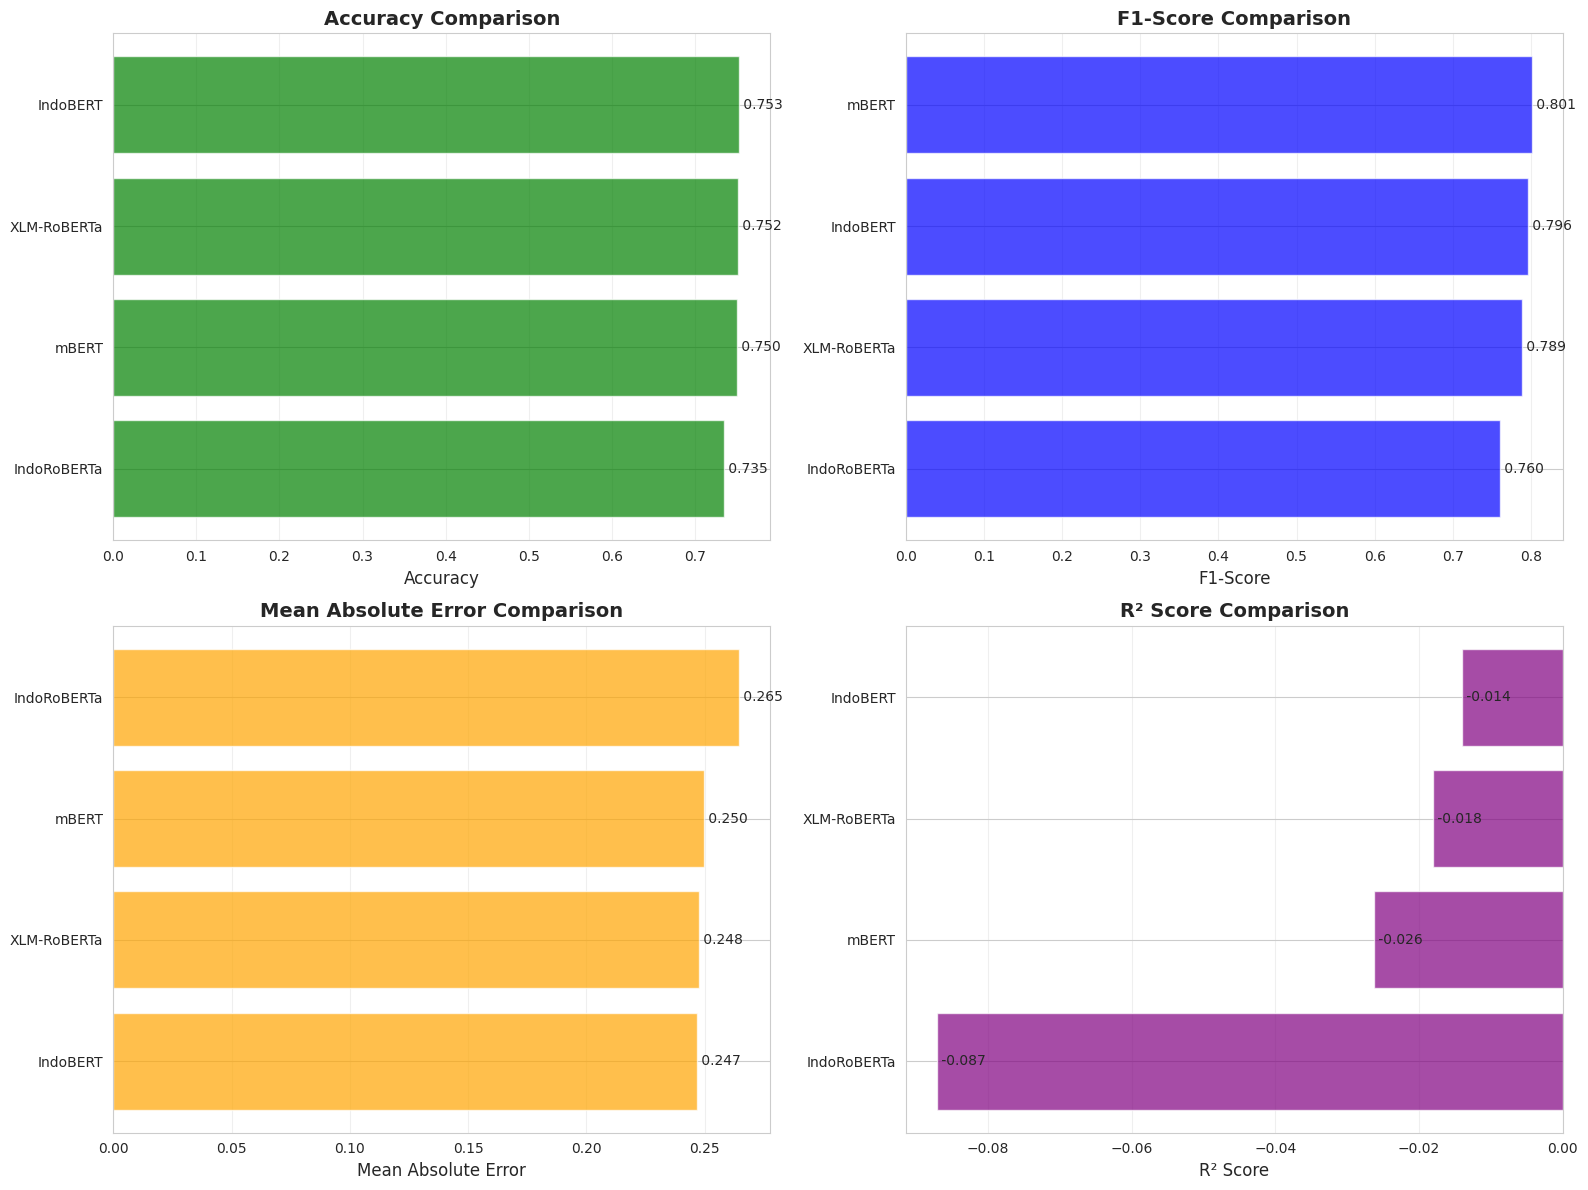

In [50]:
# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics_to_plot = [
    ('Accuracy', 'Accuracy', 'green'),
    ('F1-Score', 'F1-Score', 'blue'),
    ('MAE', 'Mean Absolute Error', 'orange'),
    ('R²', 'R² Score', 'purple')
]

for idx, (metric, title, color) in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    data = comparison_df.sort_values(metric, ascending=False)
    ax.barh(data['Model'], data[metric], color=color, alpha=0.7)
    ax.set_xlabel(title, fontsize=12)
    ax.set_title(f'{title} Comparison', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

    # Add value labels
    for i, (model, value) in enumerate(zip(data['Model'], data[metric])):
        ax.text(value, i, f' {value:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

The results indicate that mBERT resulting the most balanced overall performance among all models, achieving the highest F1-score while maintaining comparable accuracy to the other top-performing models. Although differences in MAE and R² are relatively small across models, mBERT’s higher F1-score and strong recall showing its ability to capture economic ideological signals more comprehensively, making it particularly well-suited for political ideology mapping tasks where missing signals can introduce bias.

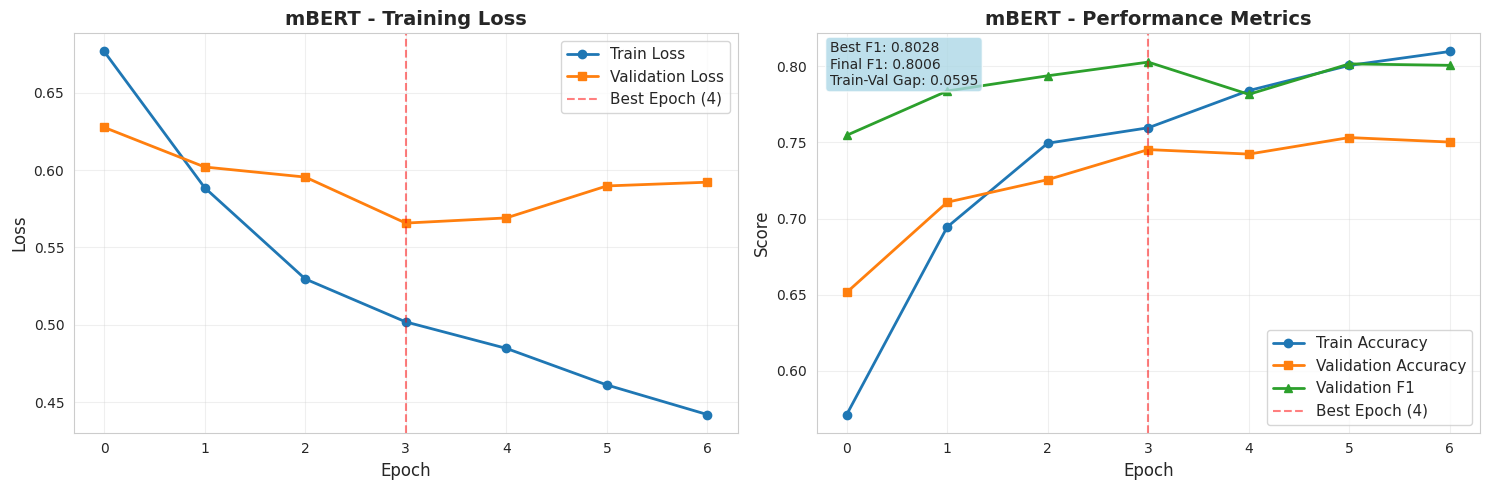


✓ Saved: mBERT_training_history.png


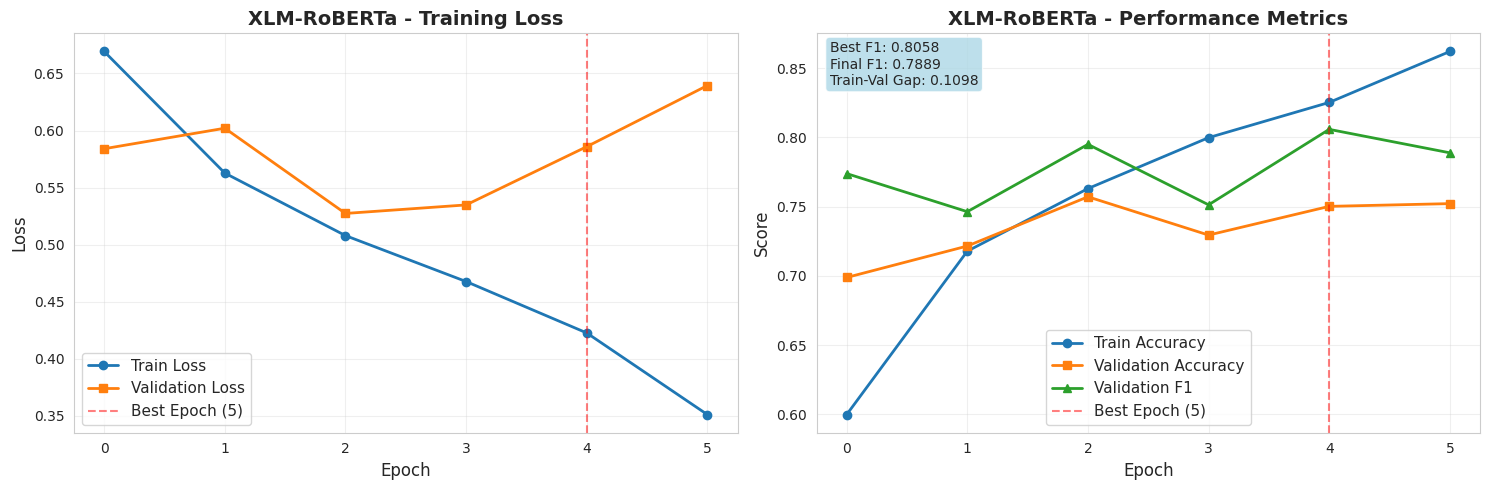


✓ Saved: XLM-RoBERTa_training_history.png


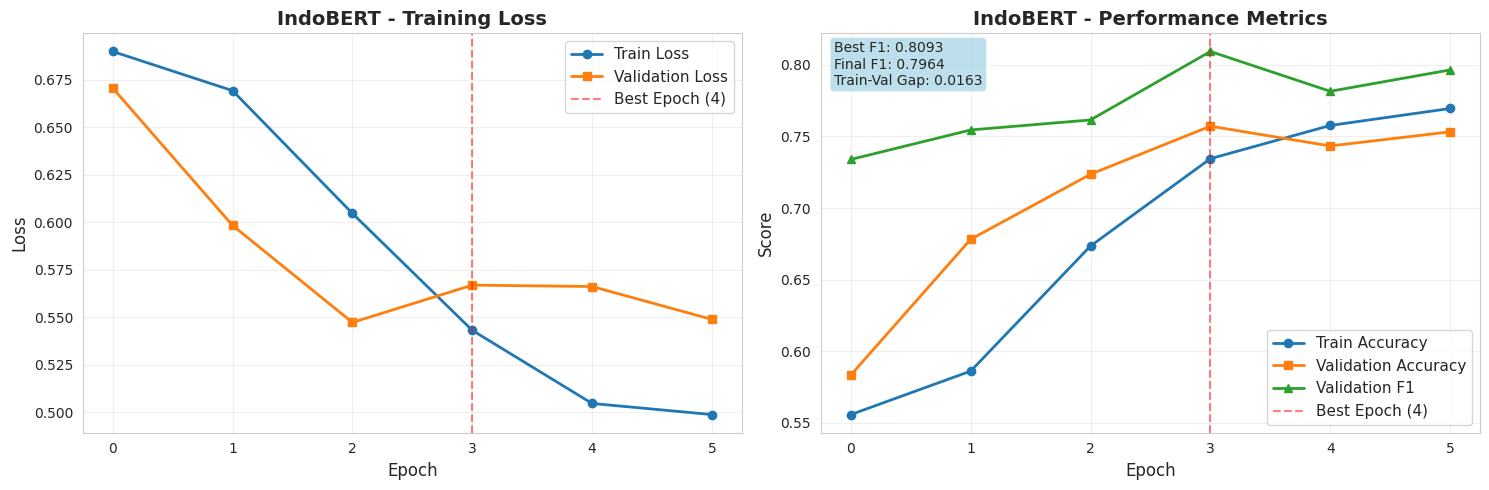


✓ Saved: IndoBERT_training_history.png


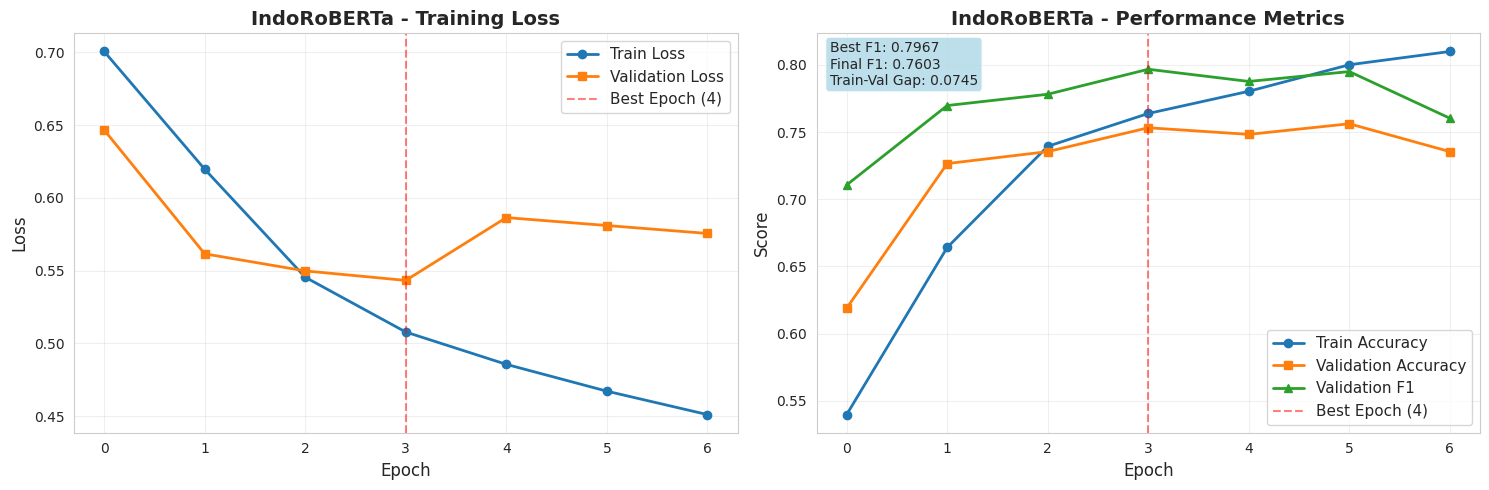


✓ Saved: IndoRoBERTa_training_history.png


In [51]:
for model_name, result in results.items():
    if result['history'] is None:
        print(f"\nSkipping {model_name} - no training history (loaded from checkpoint)")
        continue

    history = result['history']

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Loss
    axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2, markersize=6)
    axes[0].plot(history['val_loss'], label='Validation Loss', marker='s', linewidth=2, markersize=6)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title(f'{model_name} - Training Loss', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(alpha=0.3)

    # Mark best epoch
    best_epoch_idx = history['val_f1'].index(max(history['val_f1']))
    axes[0].axvline(x=best_epoch_idx, color='red', linestyle='--', alpha=0.5, label=f'Best Epoch ({best_epoch_idx+1})')
    axes[0].legend(fontsize=11)

    # Accuracy & F1
    axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2, markersize=6)
    axes[1].plot(history['val_acc'], label='Validation Accuracy', marker='s', linewidth=2, markersize=6)
    axes[1].plot(history['val_f1'], label='Validation F1', marker='^', linewidth=2, markersize=6)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Score', fontsize=12)
    axes[1].set_title(f'{model_name} - Performance Metrics', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(alpha=0.3)

    # Mark best epoch
    axes[1].axvline(x=best_epoch_idx, color='red', linestyle='--', alpha=0.5, label=f'Best Epoch ({best_epoch_idx+1})')
    axes[1].legend(fontsize=11)

    # Add statistics box
    final_f1 = result['final_metrics']['f1']
    best_f1 = max(history['val_f1'])
    train_val_gap = history['train_acc'][-1] - history['val_acc'][-1]

    stats_text = f"Best F1: {best_f1:.4f}\nFinal F1: {final_f1:.4f}\nTrain-Val Gap: {train_val_gap:.4f}"
    axes[1].text(0.02, 0.98, stats_text,
                transform=axes[1].transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

    plt.tight_layout()
    plt.savefig(f'{model_name}_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n✓ Saved: {model_name}_training_history.png")


The training curves show that mBERT shows the most stable and consistent learning behavior, with steadily decreasing training and validation loss and synchronized improvements in accuracy and F1-score across epochs. In contrast, XLM-RoBERTa and IndoRoBERTa peak earlier and show signs of overfitting, while IndoBERT improves steadily but with more fluctuations. Overall, mBERT's smooth convergence and late performance peak indicate better generalization and explain its superior final evaluation results.

In [52]:
# Save all results
results_summary = {
    model_name: {
        'final_metrics': result['final_metrics'],
        'history': result['history']
    }
    for model_name, result in results.items()
}

with open('training_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print("\n Results saved to training_results.json")


 Results saved to training_results.json


Summarizes the training results of all models and saves the key information final evaluation metrics and training history into a single JSON file. 

In [55]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [57]:
!cp -r /content/result /content/drive/MyDrive/

^C


In [58]:
!zip -r result.zip /content/result


  adding: content/result/ (stored 0%)
  adding: content/result/IndoRoBERTa_training_history.png (deflated 11%)
  adding: content/result/model_comparison.png (deflated 32%)
  adding: content/result/IndoBERT_training_history.png (deflated 10%)
  adding: content/result/models/ (stored 0%)
  adding: content/result/models/mBERT_social_axis.pt (deflated 7%)
  adding: content/result/models/IndoRoBERTa_social_axis.pt (deflated 7%)
  adding: content/result/models/XLM-RoBERTa_social_axis.pt (deflated 29%)
  adding: content/result/models/IndoBERT_social_axis.pt (deflated 7%)
  adding: content/result/mBERT_training_history.png (deflated 11%)
  adding: content/result/XLM-RoBERTa_training_history.png (deflated 11%)
  adding: content/result/training_results.json (deflated 71%)


In [59]:
!cp result.zip /content/drive/MyDrive/
